# Dataset review

This notebook starts the dataset review for the European Power Mix Analysis project.

This is an investigation on whether nuclear-heavy European electricity systems are associated with cheaper, cleaner or less volatile electricity, and what Austria’s non-nuclear model reveals.

Countries included:
- Austria
- United Kingdom
- France
- Germany
- Czechia
- Slovakia

In [3]:
import pandas as pd
import numpy as np

In [4]:
countries = [
    "Austria",
    "United Kingdom",
    "France",
    "Germany",
    "Czechia",
    "Slovakia"
]

## Data source plan

First dataset: Ember electricity data.

Aim:
- Load generation mix data.
- Filter to the selected countries.
- Compare nuclear, hydro, gas, fossil and renewable shares.
- Keep price and carbon interpretation separate until source checks are complete.

In [5]:
from pathlib import Path

project_root = Path.cwd().parent
project_root

WindowsPath('C:/Users/Tristan/Projects/nuclear-prices-carbon-europe')

In [6]:
data_raw = project_root / "data" / "raw"
data_processed = project_root / "data" / "processed"

data_raw, data_processed

(WindowsPath('C:/Users/Tristan/Projects/nuclear-prices-carbon-europe/data/raw'),
 WindowsPath('C:/Users/Tristan/Projects/nuclear-prices-carbon-europe/data/processed'))

## Load Ember data

This section loads the first raw electricity dataset and checks the columns, countries, units and available years before doing any analysis 

In [7]:
raw_files = list(data_raw.glob("*"))

raw_files

[WindowsPath('C:/Users/Tristan/Projects/nuclear-prices-carbon-europe/data/raw/ember'),
 WindowsPath('C:/Users/Tristan/Projects/nuclear-prices-carbon-europe/data/raw/eurostat'),
 WindowsPath('C:/Users/Tristan/Projects/nuclear-prices-carbon-europe/data/raw/nrg_pc_205__custom_21296387_linear.csv')]

In [8]:
ember_dir = data_raw / "ember"

ember_files = [p for p in ember_dir.rglob("*") if p.is_file()]
ember_files

[WindowsPath('C:/Users/Tristan/Projects/nuclear-prices-carbon-europe/data/raw/ember/ember_yearly_electricity_data.csv')]

In [9]:
file_path = ember_files[0]

df = pd.read_csv(file_path)

df.head()

,Area,ISO 3 code,Year,Area type,Continent,Ember region,EU,OECD,G20,G7,ASEAN,Category,Subcategory,Variable,Unit,Value,YoY absolute change,YoY % change
0,Afghanistan,AFG,2000,Country or economy,Asia,Asia,0.0,0.0,0.0,0.0,0.0,Capacity,Aggregate fuel,Clean,GW,0.19,NaN,NaN
1,Afghanistan,AFG,2000,Country or economy,Asia,Asia,0.0,0.0,0.0,0.0,0.0,Capacity,Aggregate fuel,Fossil,GW,0.03,NaN,NaN
2,Afghanistan,AFG,2000,Country or economy,Asia,Asia,0.0,0.0,0.0,0.0,0.0,Capacity,Aggregate fuel,Gas and Other Fossil,GW,0.03,NaN,NaN
3,Afghanistan,AFG,2000,Country or economy,Asia,Asia,0.0,0.0,0.0,0.0,0.0,Capacity,Aggregate fuel,"Hydro, Bioenergy and Other Renewables",GW,0.19,NaN,NaN
4,Afghanistan,AFG,2000,Country or economy,Asia,Asia,0.0,0.0,0.0,0.0,0.0,Capacity,Aggregate fuel,Renewables,GW,0.19,NaN,NaN


In [10]:
df.shape

(371020, 18)

In [11]:
df.columns

Index(['Area', 'ISO 3 code', 'Year', 'Area type', 'Continent', 'Ember region',
       'EU', 'OECD', 'G20', 'G7', 'ASEAN', 'Category', 'Subcategory',
       'Variable', 'Unit', 'Value', 'YoY absolute change', 'YoY % change'],
      dtype='object')

In [12]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

df.columns

Index(['area', 'iso_3_code', 'year', 'area_type', 'continent', 'ember_region',
       'eu', 'oecd', 'g20', 'g7', 'asean', 'category', 'subcategory',
       'variable', 'unit', 'value', 'yoy_absolute_change', 'yoy_%_change'],
      dtype='object')

In [13]:
df_selected = df[df["area"].isin(countries)].copy()

df_selected.shape

(10167, 18)

In [14]:
df_selected["area"].unique()

array(['Austria', 'Czechia', 'France', 'Germany', 'Slovakia',
       'United Kingdom'], dtype=object)

In [15]:
df_selected["category"].value_counts()

category
Electricity generation    4816
Power sector emissions    2642
Capacity                  2241
Electricity demand         312
Electricity imports        156
Name: count, dtype: int64

In [16]:
df_selected["variable"].value_counts().head(40)

variable
Clean                                    618
Coal                                     618
Solar                                    618
Other Fossil                             618
Fossil                                   618
Hydro                                    618
Gas                                      618
Nuclear                                  618
Bioenergy                                618
Wind and Solar                           618
Renewables                               618
Hydro, Bioenergy and Other Renewables    618
Gas and Other Fossil                     618
Wind                                     602
Other Renewables                         595
Demand                                   156
Demand per capita                        156
Total Generation                         156
Net Imports                              156
CO2 intensity                            156
Total emissions                          156
Name: count, dtype: int64

In [17]:
df_selected["unit"].value_counts()

unit
TWh         2798
mtCO2       2486
%           2330
GW          2241
MWh          156
gCO2/kWh     156
Name: count, dtype: int64

## First generation mix table

This section filters Ember electricity generation data to the selected countries and key generation sources.

This is measured generation data, not a claim that any one technology causes lower prices or lower emissions.

In [18]:
df_selected["year"].min(), df_selected["year"].max()

(2000, 2025)

In [19]:
latest_year = 2024
latest_year

2024

The latest full year, 2024, was selected. Electricity in TWh:

In [20]:
generation = df_selected[
    (df_selected["category"] == "Electricity generation") &
    (df_selected["unit"] == "TWh") &
    (df_selected["year"] == latest_year)
].copy()

In [21]:
generation.head()

,area,iso_3_code,year,area_type,continent,ember_region,eu,oecd,g20,g7,asean,category,subcategory,variable,unit,value,yoy_absolute_change,yoy_%_change
23058,Austria,AUT,2024,Country or economy,Europe,Europe,1.0,1.0,0.0,0.0,0.0,Electricity generation,Aggregate fuel,Clean,TWh,67.66,7.50,12.47
23059,Austria,AUT,2024,Country or economy,Europe,Europe,1.0,1.0,0.0,0.0,0.0,Electricity generation,Aggregate fuel,Fossil,TWh,10.81,-0.01,-0.09
23060,Austria,AUT,2024,Country or economy,Europe,Europe,1.0,1.0,0.0,0.0,0.0,Electricity generation,Aggregate fuel,Gas and Other Fossil,TWh,10.81,-0.01,-0.09
23061,Austria,AUT,2024,Country or economy,Europe,Europe,1.0,1.0,0.0,0.0,0.0,Electricity generation,Aggregate fuel,"Hydro, Bioenergy and Other Renewables",TWh,50.38,5.15,11.39
23062,Austria,AUT,2024,Country or economy,Europe,Europe,1.0,1.0,0.0,0.0,0.0,Electricity generation,Aggregate fuel,Renewables,TWh,67.66,7.50,12.47


Main sources of Electricity

In [22]:
main_sources = [
    "Nuclear",
    "Hydro",
    "Gas",
    "Coal",
    "Wind",
    "Solar",
    "Bioenergy",
    "Other Fossil",
    "Other Renewables"
]

In [23]:
generation_main = generation[generation["variable"].isin(main_sources)].copy()

In [24]:
generation_main[["area", "year", "variable", "unit", "value"]].head(20)

,area,year,variable,unit,value
23073,Austria,2024,Bioenergy,TWh,4.67
23074,Austria,2024,Coal,TWh,0.00
23075,Austria,2024,Gas,TWh,7.54
23076,Austria,2024,Hydro,TWh,45.71
23077,Austria,2024,Nuclear,TWh,0.00
23078,Austria,2024,Other Fossil,TWh,3.27
23079,Austria,2024,Other Renewables,TWh,0.00
23080,Austria,2024,Solar,TWh,8.14
23081,Austria,2024,Wind,TWh,9.14
87121,Czechia,2024,Bioenergy,TWh,5.38


In [25]:
generation_mix_table = generation_main.pivot_table(
    index="area",
    columns="variable",
    values="value",
    aggfunc="sum"
).fillna(0)

generation_mix_table

variable,Bioenergy,Coal,Gas,Hydro,Nuclear,Other Fossil,Other Renewables,Solar,Wind
area,,,,,,,,,
Austria,4.67,0.00,7.54,45.71,0.00,3.27,0.00,8.14,9.14
Czechia,5.38,26.52,3.79,2.66,29.70,0.50,0.00,3.59,0.67
France,10.68,1.02,18.10,71.12,380.45,9.54,0.57,24.87,45.43
Germany,51.08,106.33,78.41,23.83,0.00,20.39,0.22,74.13,141.60
Slovakia,1.58,0.52,2.88,4.83,18.23,0.79,0.00,0.69,0.00
United Kingdom,40.09,1.90,86.30,5.76,40.59,11.45,0.00,14.79,83.28


In [26]:
generation_mix_share = generation_mix_table.div(
    generation_mix_table.sum(axis=1),
    axis=0
) * 100

generation_mix_share.round(1)

variable,Bioenergy,Coal,Gas,Hydro,Nuclear,Other Fossil,Other Renewables,Solar,Wind
area,,,,,,,,,
Austria,6.0,0.0,9.6,58.3,0.0,4.2,0.0,10.4,11.6
Czechia,7.4,36.4,5.2,3.7,40.8,0.7,0.0,4.9,0.9
France,1.9,0.2,3.2,12.7,67.7,1.7,0.1,4.4,8.1
Germany,10.3,21.4,15.8,4.8,0.0,4.1,0.0,14.9,28.5
Slovakia,5.4,1.8,9.8,16.4,61.8,2.7,0.0,2.3,0.0
United Kingdom,14.1,0.7,30.4,2.0,14.3,4.0,0.0,5.2,29.3


## Initial observations*

For the latest full year (2024) in the Ember dataset:

- Austria appears hydro-heavy, with no nuclear generation in this table
- France and Slovakia are on the side of nuclear-heavy when compared to other countries
- Czechia combines nuclear with a large coal share
- Germany has high wind and solar shares, but still shows material coal and gas generation
- The United Kingdom shows a large gas and wind share, with a smaller nuclear share

*These are descriptive observations only. They do not show that any technology causes lower prices, lower emissions or lower volatility

In [27]:
key_mix_summary = generation_mix_share[
    ["Nuclear", "Hydro", "Gas", "Coal", "Wind", "Solar"]
].round(1)

key_mix_summary

variable,Nuclear,Hydro,Gas,Coal,Wind,Solar
area,,,,,,
Austria,0.0,58.3,9.6,0.0,11.6,10.4
Czechia,40.8,3.7,5.2,36.4,0.9,4.9
France,67.7,12.7,3.2,0.2,8.1,4.4
Germany,0.0,4.8,15.8,21.4,28.5,14.9
Slovakia,61.8,16.4,9.8,1.8,0.0,2.3
United Kingdom,14.3,2.0,30.4,0.7,29.3,5.2


In [28]:
key_mix_summary.sort_values("Nuclear", ascending=False)

variable,Nuclear,Hydro,Gas,Coal,Wind,Solar
area,,,,,,
France,67.7,12.7,3.2,0.2,8.1,4.4
Slovakia,61.8,16.4,9.8,1.8,0.0,2.3
Czechia,40.8,3.7,5.2,36.4,0.9,4.9
United Kingdom,14.3,2.0,30.4,0.7,29.3,5.2
Austria,0.0,58.3,9.6,0.0,11.6,10.4
Germany,0.0,4.8,15.8,21.4,28.5,14.9


## Chart 1: Nuclear generation share by country

This chart ranks the selected countries by the share of electricity generation from nuclear power in the latest available Ember year.

This is a descriptive comparison only. It does not show that nuclear generation causes lower prices, lower emissions or lower volatility.

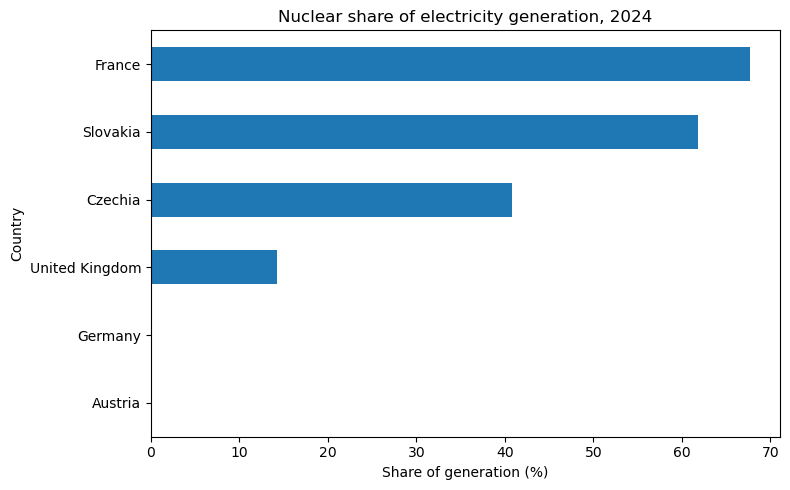

In [29]:
import matplotlib.pyplot as plt

nuclear_share = key_mix_summary["Nuclear"].sort_values()

ax = nuclear_share.plot(kind="barh", figsize=(8, 5))

ax.set_title(f"Nuclear share of electricity generation, {latest_year}")
ax.set_xlabel("Share of generation (%)")
ax.set_ylabel("Country")

plt.tight_layout()
plt.show()

In [30]:
low_carbon_cols = ["Nuclear", "Hydro", "Wind", "Solar", "Bioenergy", "Other Renewables"]
fossil_cols = ["Gas", "Coal", "Other Fossil"]

low_carbon_vs_fossil = pd.DataFrame({
    "Low-carbon share (%)": generation_mix_share[low_carbon_cols].sum(axis=1),
    "Fossil share (%)": generation_mix_share[fossil_cols].sum(axis=1)
}).round(1)

low_carbon_vs_fossil.sort_values("Low-carbon share (%)", ascending=False)

,Low-carbon share (%),Fossil share (%)
area,,
France,94.9,5.1
Austria,86.2,13.8
Slovakia,85.8,14.2
United Kingdom,64.9,35.1
Germany,58.6,41.4
Czechia,57.7,42.3


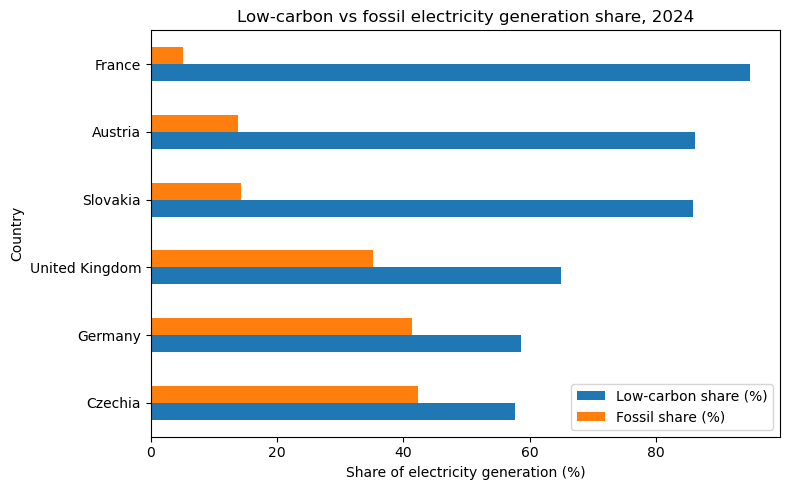

In [31]:
ax = low_carbon_vs_fossil.sort_values("Low-carbon share (%)").plot(
    kind="barh",
    figsize=(8, 5)
)

ax.set_title(f"Low-carbon vs fossil electricity generation share, {latest_year}")
ax.set_xlabel("Share of electricity generation (%)")
ax.set_ylabel("Country")

plt.tight_layout()
plt.show()

## Initial chart interpretation

The latest full Ember year used here suggests that France, Slovakia and Austria have the highest low-carbon generation shares among the selected countries.

Austria stands out as a low-nuclear comparison case: its low-carbon share appears to be mainly driven by hydro rather than nuclear generation. France and Slovakia show high low-carbon shares alongside high nuclear shares.
Germany and Czechia show lower low-carbon shares in this comparison because fossil generation remains material.

This chart describes generation mix only. It does not explain electricity prices or prove that any technology causes lower emissions.

In [32]:
carbon_intensity = df_selected[
    (df_selected["variable"] == "CO2 intensity") &
    (df_selected["unit"] == "gCO2/kWh") &
    (df_selected["year"] == latest_year)
].copy()

carbon_intensity_table = carbon_intensity[
    ["area", "year", "value"]
].rename(columns={
    "area": "Country",
    "year": "Year",
    "value": "Carbon intensity (gCO2/kWh)"
}).sort_values("Carbon intensity (gCO2/kWh)")

carbon_intensity_table

,Country,Year,Carbon intensity (gCO2/kWh)
118248,France,2024,40.48
304484,Slovakia,2024,96.55
23090,Austria,2024,103.48
350588,United Kingdom,2024,216.50
131066,Germany,2024,336.38
87138,Czechia,2024,414.23


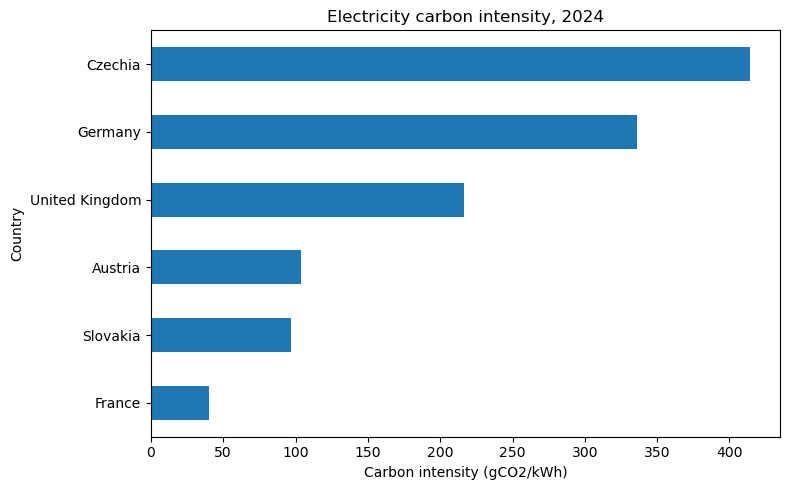

In [33]:
ax = carbon_intensity_table.set_index("Country")[
    "Carbon intensity (gCO2/kWh)"
].sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

ax.set_title(f"Electricity carbon intensity, {latest_year}")
ax.set_xlabel("Carbon intensity (gCO2/kWh)")
ax.set_ylabel("Country")

plt.tight_layout()
plt.show()

## Initial carbon intensity interpretation

The latest full Ember year used here suggests that countries with higher low-carbon generation shares tend to show lower carbon intensity in this selected group with Austria standing out as an interesting and important  comparison case due to its low nuclear generation but high low-carbon generation through hydro

France and Slovakia appear low-carbon with high nuclear generation shares.

This comparison supports the project direction, but it does not prove causation. Electricity prices, imports, exports, market design and demand patterns need separate analysis.

## Household electricity prices

This section loads Eurostat household electricity price data for the selected countries.

The comparison uses:

- household band DC: 2,500 kWh to 4,999 kWh
- all taxes and levies included
- Euro per kWh
- 2024-S2, to align with the latest full Ember year used in the generation analysis

In [34]:
household_price_path = (
    project_root
    / "data"
    / "raw"
    / "eurostat"
    / "eurostat_nrg_pc_204_household_prices.csv"
)

household_prices = pd.read_csv(household_price_path)

household_prices.columns = (
    household_prices.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

household_prices.head()

,dataflow,last_update,freq,siec,nrg_cons,unit,tax,currency,geo,time_period,obs_value,obs_flag,conf_status
0,ESTAT:NRG_PC_204(1.0),28/04/26 23:00:00,"Half-yearly, semesterly",Electricity,Consumption from 2 500 kWh to 4 999 kWh - band DC,Kilowatt-hour,All taxes and levies included,Euro,Austria,2007-S2,0.1740,NaN,NaN
1,ESTAT:NRG_PC_204(1.0),28/04/26 23:00:00,"Half-yearly, semesterly",Electricity,Consumption from 2 500 kWh to 4 999 kWh - band DC,Kilowatt-hour,All taxes and levies included,Euro,Austria,2008-S1,0.1779,NaN,NaN
2,ESTAT:NRG_PC_204(1.0),28/04/26 23:00:00,"Half-yearly, semesterly",Electricity,Consumption from 2 500 kWh to 4 999 kWh - band DC,Kilowatt-hour,All taxes and levies included,Euro,Austria,2008-S2,0.1772,NaN,NaN
3,ESTAT:NRG_PC_204(1.0),28/04/26 23:00:00,"Half-yearly, semesterly",Electricity,Consumption from 2 500 kWh to 4 999 kWh - band DC,Kilowatt-hour,All taxes and levies included,Euro,Austria,2009-S1,0.1909,NaN,NaN
4,ESTAT:NRG_PC_204(1.0),28/04/26 23:00:00,"Half-yearly, semesterly",Electricity,Consumption from 2 500 kWh to 4 999 kWh - band DC,Kilowatt-hour,All taxes and levies included,Euro,Austria,2009-S2,0.1909,NaN,NaN


In [35]:
# Check that the downloaded file contains the intended filter choices


for col in ["geo", "nrg_cons", "tax", "currency", "unit", "time_period"]:
    print(f"\n{col}")
    print(sorted(household_prices[col].dropna().unique()))


geo
['Austria', 'Czechia', 'France', 'Germany', 'Slovakia', 'United Kingdom']

nrg_cons
['Consumption from 2 500 kWh to 4 999 kWh - band DC']

tax
['All taxes and levies included']

currency
['Euro']

unit
['Kilowatt-hour']

time_period
['2007-S1', '2007-S2', '2008-S1', '2008-S2', '2009-S1', '2009-S2', '2010-S1', '2010-S2', '2011-S1', '2011-S2', '2012-S1', '2012-S2', '2013-S1', '2013-S2', '2014-S1', '2014-S2', '2015-S1', '2015-S2', '2016-S1', '2016-S2', '2017-S1', '2017-S2', '2018-S1', '2018-S2', '2019-S1', '2019-S2', '2020-S1', '2020-S2', '2021-S1', '2021-S2', '2022-S1', '2022-S2', '2023-S1', '2023-S2', '2024-S1', '2024-S2', '2025-S1', '2025-S2']


In [36]:
price_period = "2024-S2"

hh_2024_s2 = household_prices[
    (household_prices["geo"].isin(countries))
    & (household_prices["time_period"] == price_period)
].copy()

hh_2024_s2["obs_value"] = pd.to_numeric(
    hh_2024_s2["obs_value"],
    errors="coerce"
)

household_price_latest_table = (
    hh_2024_s2[["geo", "time_period", "obs_value"]]
    .rename(columns={
        "geo": "Country",
        "time_period": "Price period",
        "obs_value": "Household price EUR/kWh"
    })
    .sort_values("Household price EUR/kWh")
    .reset_index(drop=True)
)

household_price_latest_table

,Country,Price period,Household price EUR/kWh
0,Slovakia,2024-S2,0.1770
1,Austria,2024-S2,0.2437
2,France,2024-S2,0.2926
3,Czechia,2024-S2,0.3302
4,Germany,2024-S2,0.3943


### Price period note

Eurostat household price data is available through 2025-S2 in this download. The joined country summary uses 2024-S2 so that the price comparison aligns with the latest full Ember generation year used in this notebook.

A separate price-only view can use 2025-S2.

In [37]:
# Check which price periods contain all six selected countries 
selected_countries = set(countries)

price_coverage = (
    household_prices
    .groupby("time_period")["geo"]
    .apply(lambda x: sorted(set(x)))
    .reset_index(name="countries_present")
)

price_coverage["country_count"] = price_coverage["countries_present"].apply(len)

# Keep only periods where all six countries are present.
common_price_periods = price_coverage[
    price_coverage["country_count"] == len(selected_countries)
].copy()

common_price_periods.tail(10)

,time_period,countries_present,country_count
17,2015-S2,"[Austria, Czechia, France, Germany, Slovakia, ...",6
18,2016-S1,"[Austria, Czechia, France, Germany, Slovakia, ...",6
19,2016-S2,"[Austria, Czechia, France, Germany, Slovakia, ...",6
20,2017-S1,"[Austria, Czechia, France, Germany, Slovakia, ...",6
21,2017-S2,"[Austria, Czechia, France, Germany, Slovakia, ...",6
22,2018-S1,"[Austria, Czechia, France, Germany, Slovakia, ...",6
23,2018-S2,"[Austria, Czechia, France, Germany, Slovakia, ...",6
24,2019-S1,"[Austria, Czechia, France, Germany, Slovakia, ...",6
25,2019-S2,"[Austria, Czechia, France, Germany, Slovakia, ...",6
26,2020-S1,"[Austria, Czechia, France, Germany, Slovakia, ...",6


In [38]:
# Latest Eurostat period where all six selected countries have household price data


latest_common_price_period = common_price_periods["time_period"].max()

latest_common_price_period

'2020-S1'

In [39]:
# Check whether any country, especially the United Kingdom, stops earlier than the others.
latest_price_by_country = (
    household_prices[household_prices["geo"].isin(countries)]
    .sort_values("time_period")
    .groupby("geo")
    .tail(1)
    [["geo", "time_period", "obs_value"]]
    .rename(columns={
        "geo": "Country",
        "time_period": "Latest price period",
        "obs_value": "Household price EUR/kWh"
    })
    .sort_values("Country")
    .reset_index(drop=True)
)

latest_price_by_country

,Country,Latest price period,Household price EUR/kWh
0,Austria,2025-S2,0.3272
1,Czechia,2025-S2,0.3217
2,France,2025-S2,0.2561
3,Germany,2025-S2,0.3869
4,Slovakia,2025-S2,0.1853
5,United Kingdom,2020-S1,0.2203


### Price coverage decision

The main household price comparison uses the latest same-period Eurostat data available in this download: 2025-S2.

The United Kingdom is excluded from the main latest-price comparison because its latest available Eurostat household price value in this file is 2020-S1. Including the UK with a 2020-S1 value would make the chart look complete, but it would not reflect recent European price changes after Covid, the gas crisis and the 2022 energy shock.

The UK is kept visible as a data coverage limitation.

In [40]:
# Check latest available price period by country.
latest_price_by_country = (
    household_prices[household_prices["geo"].isin(countries)]
    .sort_values("time_period")
    .groupby("geo")
    .tail(1)
    [["geo", "time_period", "obs_value"]]
    .rename(columns={
        "geo": "Country",
        "time_period": "Latest price period",
        "obs_value": "Household price EUR/kWh"
    })
    .sort_values("Country")
    .reset_index(drop=True)
)

latest_price_by_country["Household price EUR/kWh"] = pd.to_numeric(
    latest_price_by_country["Household price EUR/kWh"],
    errors="coerce"
)

latest_price_by_country

,Country,Latest price period,Household price EUR/kWh
0,Austria,2025-S2,0.3272
1,Czechia,2025-S2,0.3217
2,France,2025-S2,0.2561
3,Germany,2025-S2,0.3869
4,Slovakia,2025-S2,0.1853
5,United Kingdom,2020-S1,0.2203


In [41]:
# Main price comparison: latest same period with available Eurostat coverage


latest_price_period = "2025-S2"

household_price_latest_same_period = household_prices[
    (household_prices["geo"].isin(countries))
    & (household_prices["time_period"] == latest_price_period)
].copy()

household_price_latest_same_period["obs_value"] = pd.to_numeric(
    household_price_latest_same_period["obs_value"],
    errors="coerce"
)

household_price_latest_same_period_table = (
    household_price_latest_same_period[["geo", "time_period", "obs_value"]]
    .rename(columns={
        "geo": "Country",
        "time_period": "Price period",
        "obs_value": "Household price EUR/kWh"
    })
    .sort_values("Household price EUR/kWh")
    .reset_index(drop=True)
)

household_price_latest_same_period_table

,Country,Price period,Household price EUR/kWh
0,Slovakia,2025-S2,0.1853
1,France,2025-S2,0.2561
2,Czechia,2025-S2,0.3217
3,Austria,2025-S2,0.3272
4,Germany,2025-S2,0.3869


In [42]:
# UK is shown separately because it does not have 2025-S2 coverage in this file
uk_price_coverage_note = latest_price_by_country[
    latest_price_by_country["Country"] == "United Kingdom"
]

uk_price_coverage_note

,Country,Latest price period,Household price EUR/kWh
5,United Kingdom,2020-S1,0.2203


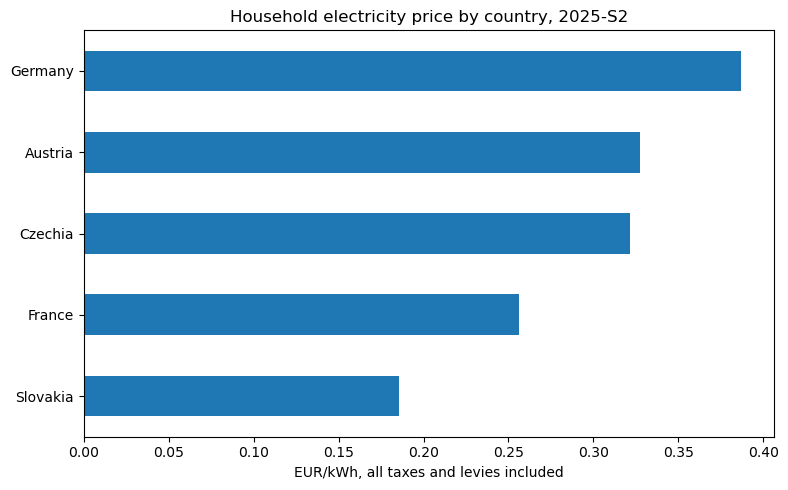

In [43]:
ax = household_price_latest_same_period_table.set_index("Country")[
    "Household price EUR/kWh"
].sort_values().plot(
    kind="barh",
    figsize=(8, 5),
    title=f"Household electricity price by country, {latest_price_period}"
)

ax.set_xlabel("EUR/kWh, all taxes and levies included")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

The chart excludes the United Kingdom because this Eurostat household price download does not include a UK value for 2025-S2. The latest available UK value in this file is 2020-S1, so it is not mixed into the current price comparison.

In [44]:
# Combine 2024 generation/carbon data with latest 2025-S2 household prices where available 
country_summary_latest_price = (
    key_mix_summary
    .reset_index()
    .rename(columns={"area": "Country"})
    .merge(
        low_carbon_vs_fossil.reset_index().rename(columns={"area": "Country"}),
        on="Country",
        how="left"
    )
    .merge(
        carbon_intensity_table,
        on="Country",
        how="left"
    )
    .merge(
        household_price_latest_same_period_table,
        on="Country",
        how="left"
    )
)

country_summary_latest_price["Price coverage note"] = country_summary_latest_price[
    "Household price EUR/kWh"
].isna().map({
    True: "No 2025-S2 Eurostat household price in this download",
    False: "2025-S2 Eurostat household price available"
})

country_summary_latest_price

,Country,Nuclear,Hydro,Gas,Coal,Wind,Solar,Low-carbon share (%),Fossil share (%),Year,Carbon intensity (gCO2/kWh),Price period,Household price EUR/kWh,Price coverage note
0,Austria,0.0,58.3,9.6,0.0,11.6,10.4,86.2,13.8,2024,103.48,2025-S2,0.3272,2025-S2 Eurostat household price available
1,Czechia,40.8,3.7,5.2,36.4,0.9,4.9,57.7,42.3,2024,414.23,2025-S2,0.3217,2025-S2 Eurostat household price available
2,France,67.7,12.7,3.2,0.2,8.1,4.4,94.9,5.1,2024,40.48,2025-S2,0.2561,2025-S2 Eurostat household price available
3,Germany,0.0,4.8,15.8,21.4,28.5,14.9,58.6,41.4,2024,336.38,2025-S2,0.3869,2025-S2 Eurostat household price available
4,Slovakia,61.8,16.4,9.8,1.8,0.0,2.3,85.8,14.2,2024,96.55,2025-S2,0.1853,2025-S2 Eurostat household price available
5,United Kingdom,14.3,2.0,30.4,0.7,29.3,5.2,64.9,35.1,2024,216.50,NaN,NaN,No 2025-S2 Eurostat household price in this do...


### Joined summary note

This table combines 2024 Ember generation and carbon-intensity indicators with 2025-S2 Eurostat household prices where available.

It should not be read as a same-year causal comparison. The price column is included as a recent household price reference, while the coverage note flags where current Eurostat price data is missing.

## Animated bubble chart: nuclear share vs carbon intensity

This chart tracks how each selected country moves through the nuclear-share and carbon-intensity space from 2000 to 2024.

- X-axis: nuclear generation share (%)
- Y-axis: power-sector carbon intensity (gCO₂/kWh)
- Bubble size: total electricity generation (TWh)
- Colour: country
- Animation frame: year

Please treat this as a descriptive comparison only as it is only showing moment and accociation - not causation 

In [45]:
# Build a country-year table for the animated comparison.
generation_share = df_selected[
    (df_selected["category"] == "Electricity generation")
    & (df_selected["subcategory"] == "Fuel")
    & (df_selected["unit"] == "%")
    & (df_selected["variable"] == "Nuclear")
    & (df_selected["year"].between(2000, 2024))
].copy()

generation_total = df_selected[
    (df_selected["category"] == "Electricity generation")
    & (df_selected["variable"] == "Total Generation")
    & (df_selected["unit"] == "TWh")
    & (df_selected["year"].between(2000, 2024))
].copy()

carbon_intensity_trend = df_selected[
    (df_selected["variable"] == "CO2 intensity")
    & (df_selected["unit"] == "gCO2/kWh")
    & (df_selected["year"].between(2000, 2024))
].copy()

bubble_data = (
    generation_share[["area", "year", "value"]]
    .rename(columns={
        "area": "Country",
        "year": "Year",
        "value": "Nuclear share (%)"
    })
    .merge(
        carbon_intensity_trend[["area", "year", "value"]]
        .rename(columns={
            "area": "Country",
            "year": "Year",
            "value": "Carbon intensity (gCO2/kWh)"
        }),
        on=["Country", "Year"],
        how="inner"
    )
    .merge(
        generation_total[["area", "year", "value"]]
        .rename(columns={
            "area": "Country",
            "year": "Year",
            "value": "Total generation (TWh)"
        }),
        on=["Country", "Year"],
        how="inner"
    )
)

bubble_data.head()

,Country,Year,Nuclear share (%),Carbon intensity (gCO2/kWh),Total generation (TWh)
0,Austria,2000,0.0,203.39,59.64
1,Austria,2001,0.0,229.09,60.98
2,Austria,2002,0.0,226.13,60.63
3,Austria,2003,0.0,282.39,57.97
4,Austria,2004,0.0,259.34,61.85


In [46]:
bubble_data.groupby("Country")["Year"].agg(["min", "max", "count"])

,min,max,count
Country,,,
Austria,2000,2024,25
Czechia,2000,2024,25
France,2000,2024,25
Germany,2000,2024,25
Slovakia,2000,2024,25
United Kingdom,2000,2024,25


In [47]:
import plotly.express as px

fig = px.scatter(
    bubble_data,
    x="Nuclear share (%)",
    y="Carbon intensity (gCO2/kWh)",
    size="Total generation (TWh)",
    color="Country",
    animation_frame="Year",
    hover_name="Country",
    range_x=[0, 80],
    range_y=[0, bubble_data["Carbon intensity (gCO2/kWh)"].max() * 1.1],
    size_max=55,
    title="Nuclear share vs carbon intensity, 2000-2024"
)

fig.update_layout(
    xaxis_title="Nuclear generation share (%)",
    yaxis_title="Power-sector carbon intensity (gCO₂/kWh)",
    legend_title="Country"
)

fig.show()

In [48]:
outputs_dir = project_root / "outputs" / "charts"
outputs_dir.mkdir(parents=True, exist_ok=True)

fig.write_html(outputs_dir / "animated_nuclear_share_vs_carbon_intensity.html")

outputs_dir / "animated_nuclear_share_vs_carbon_intensity.html"

WindowsPath('C:/Users/Tristan/Projects/nuclear-prices-carbon-europe/outputs/charts/animated_nuclear_share_vs_carbon_intensity.html')

Czechia and Slovakia appear to reduce carbon intensity as nuclear share rises or remains high. However, other countries also reduce power-sector carbon intensity while nuclear share falls, which suggests that the relationship is not simply "more nuclear equals lower carbon".

## Connected scatter: direction of travel

The animated chart is useful for movement, but this connected scatter makes the direction of travel easier to inspect country by country.

Each line shows how one country moves through nuclear share and carbon intensity from 2000 to 2024. Year labels are added at 2000, 2010, 2020 and 2024 to avoid clutter.

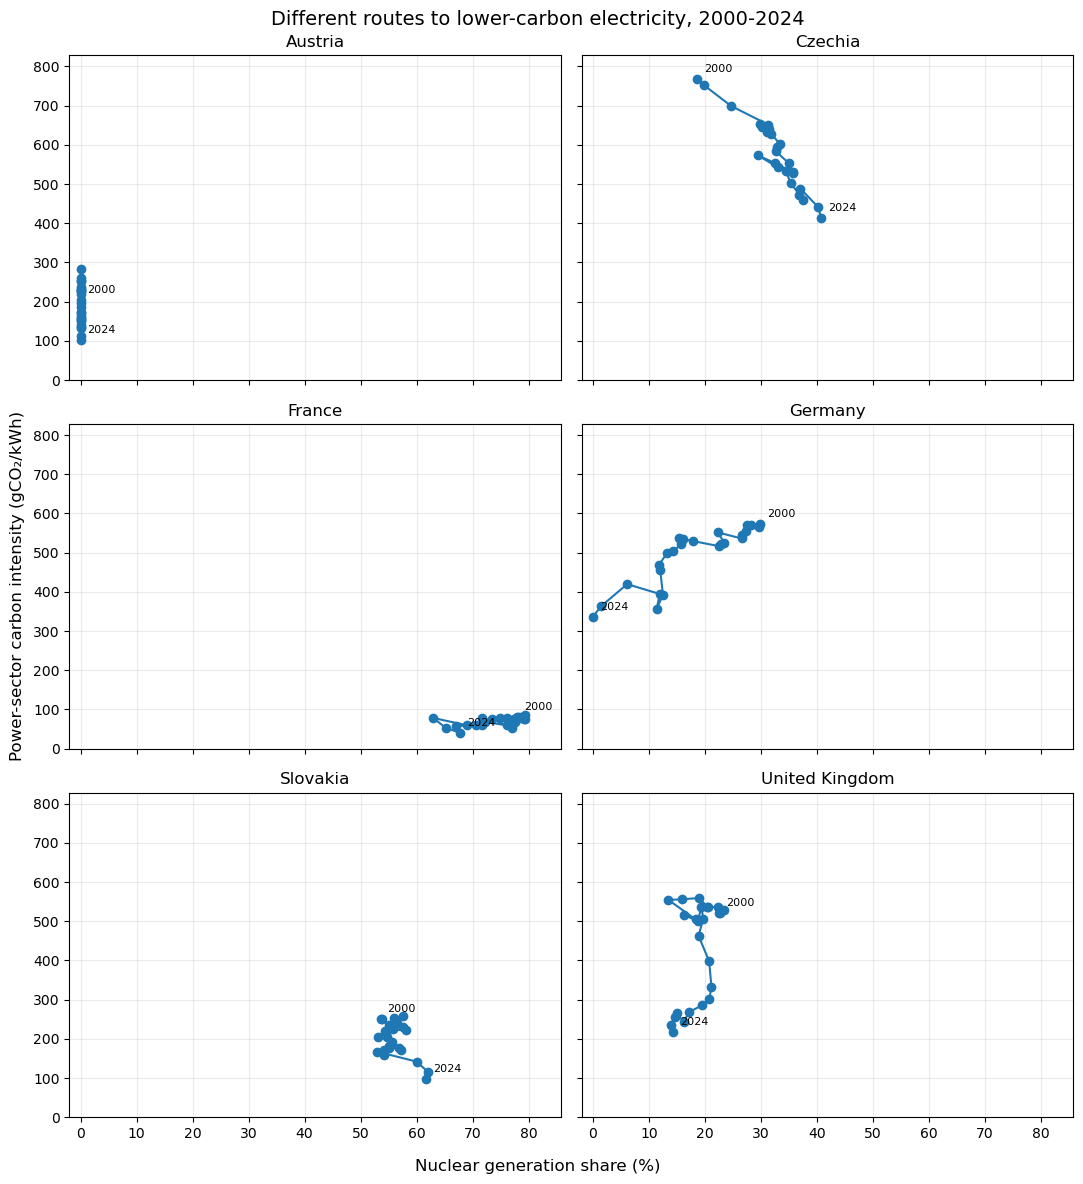

In [54]:
# Connected scatter small multiples: one compact panel per country.
label_years = [2000, 2024]

countries_order = [
    "Austria",
    "Czechia",
    "France",
    "Germany",
    "Slovakia",
    "United Kingdom"
]

fig, axes = plt.subplots(3, 2, figsize=(11, 12), sharex=True, sharey=True)
axes = axes.flatten()

x_max = bubble_data["Nuclear share (%)"].max() * 1.08
y_max = bubble_data["Carbon intensity (gCO2/kWh)"].max() * 1.08

for ax, country in zip(axes, countries_order):
    country_data = (
        bubble_data[bubble_data["Country"] == country]
        .sort_values("Year")
        .copy()
    )

    ax.plot(
        country_data["Nuclear share (%)"],
        country_data["Carbon intensity (gCO2/kWh)"],
        marker="o",
        linewidth=1.5
    )

    # Label only the start and end years to reduce clutter.
    for _, row in country_data[country_data["Year"].isin(label_years)].iterrows():
        ax.annotate(
            str(int(row["Year"])),
            (
                row["Nuclear share (%)"],
                row["Carbon intensity (gCO2/kWh)"]
            ),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=8
        )

    ax.set_title(country)
    ax.set_xlim(-2, x_max)
    ax.set_ylim(0, y_max)
    ax.grid(True, alpha=0.25)

fig.suptitle(
    "Different routes to lower-carbon electricity, 2000-2024",
    fontsize=14
)

fig.supxlabel("Nuclear generation share (%)")
fig.supylabel("Power-sector carbon intensity (gCO₂/kWh)")

outputs_dir = project_root / "outputs" / "charts"
outputs_dir.mkdir(parents=True, exist_ok=True)

fig.savefig(
    outputs_dir / "connected_scatter_nuclear_share_carbon_intensity_2000_2024.png",
    dpi=200,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

This chart shows how each selected country moved through the nuclear-share and carbon-intensity space from 2000 to 2024.

Each panel uses the same axes, so the countries can be compared fairly. The labels show only 2000 and 2024 to keep the chart readable.

### Initial interpretation

Czechia and Slovakia appear to reduce carbon intensity while nuclear share rises or remains high

However, Germany and the United Kingdom also reduce power-sector carbon intensity while nuclear share falls. Austria reduces carbon intensity with no nuclear generation at all.

This makes the chart more useful than a simple nuclear-vs-carbon argument: it shows different low-carbon pathways rather than one universal route.